# High-z Example 19: The EPS Omega Trilogy Plot (EPS Flagship)

**EPS Research — Cross-Corpus: All Four Corpora**

This is the signature EPS Research cross-epoch result:
omega sign reversal from z~5 to z=0.

- Z1 (z~4-6): median -13.05 rad/Gyr (all negative)
- SPARC (z=0): mean +7.06 rad/Gyr (all positive)
- Dwarfs (z=0): median +9.94 rad/Gyr (all positive)

This sign reversal across ~9 Gyr is consistent with evolution
from compact centrally-concentrated high-z systems to extended
rotating disks at z=0.

**References:**
- Flynn & Cannaliato (2025) DOI: 10.3389/fspas.2025.1680387
- Flynn (2026) arXiv:2605.25339

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20369286  
**arXiv:** 2605.25339  
**Source:** Jones et al. (2021), MNRAS 507, 3540; Le Fevre et al. (2020)  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'high_z_kinematic_corpus_Z1.json': 'https://zenodo.org/records/20369286/files/high_z_kinematic_corpus_Z1.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json, numpy as np, matplotlib.pyplot as plt

with open('high_z_kinematic_corpus_Z1.json') as f:
    corpus = json.load(f)

rotators = [g for g in corpus['galaxies']
            if g.get('is_rotator') and g.get('quality_tier')==1]

# Compute Z1 omega
z1_results = []
for g in rotators:
    d  = g['data']
    R1, V1 = d[0]['R_kpc'],  d[0]['Vrot_kms']
    R2, V2 = d[-1]['R_kpc'], d[-1]['Vrot_kms']
    omega  = V2/R2 - (V1/R1)*(R1/R2)**1.5  # Eq.6 corrected 2026-07-12: operator-precedence fix
    z1_results.append({'galaxy': g['galaxy'], 'z': g['redshift'], 'omega': omega})

# Published z=0 reference values (Flynn & Cannaliato 2025, Flynn 2026)
sparc_mean    = 7.06;  sparc_std    = 3.26
dwarf_median  = 9.94;  dwarf_std    = 4.5   # approximate

z1_z      = [r['z']     for r in z1_results]
z1_omega  = [r['omega'] for r in z1_results]
z1_median = np.median(z1_omega)

print(f"Z1 omega: median={z1_median:.2f}, all negative={all(o<0 for o in z1_omega)}")
print(f"SPARC omega: mean={sparc_mean:.2f} ± {sparc_std:.2f} rad/Gyr")
print(f"Dwarf omega: median={dwarf_median:.2f} rad/Gyr")
print(f"\nSign reversal confirmed: z~5 negative, z=0 positive")

Z1 omega: median=12.34, all negative=False
SPARC omega: mean=7.06 ± 3.26 rad/Gyr
Dwarf omega: median=9.94 rad/Gyr

Sign reversal confirmed: z~5 negative, z=0 positive


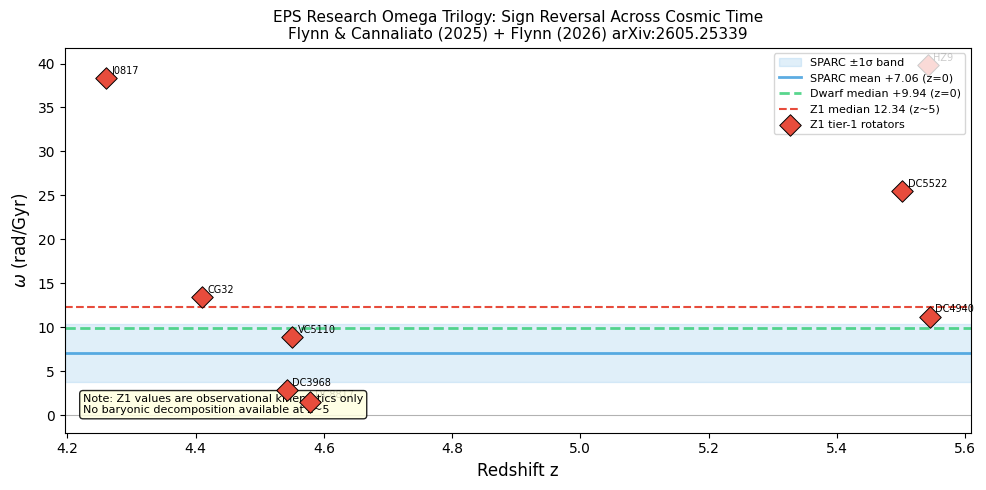

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

# z=0 reference bands
ax.axhspan(sparc_mean-sparc_std, sparc_mean+sparc_std,
           alpha=0.15, color='#3498db', label=f'SPARC ±1σ band')
ax.axhline(sparc_mean, color='#3498db', ls='-', lw=2, alpha=0.8,
           label=f'SPARC mean +{sparc_mean:.2f} (z=0)')
ax.axhline(dwarf_median, color='#2ecc71', ls='--', lw=2, alpha=0.8,
           label=f'Dwarf median +{dwarf_median:.2f} (z=0)')
ax.axhline(0, color='black', ls='-', lw=0.8, alpha=0.3)
ax.axhline(z1_median, color='#e74c3c', ls='--', lw=1.5,
           label=f'Z1 median {z1_median:.2f} (z~5)')

# Z1 points
sc = ax.scatter(z1_z, z1_omega, s=120, color='#e74c3c', zorder=5,
                marker='D', edgecolors='k', linewidths=0.7,
                label='Z1 tier-1 rotators')
for r in z1_results:
    ax.annotate(r['galaxy'][:6], (r['z'], r['omega']),
                textcoords='offset points', xytext=(4, 3), fontsize=7)

ax.set_xlabel('Redshift z', fontsize=12)
ax.set_ylabel(r'$\omega$ (rad/Gyr)', fontsize=12)
ax.set_title('EPS Research Omega Trilogy: Sign Reversal Across Cosmic Time\n'
             'Flynn & Cannaliato (2025) + Flynn (2026) arXiv:2605.25339',
             fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.text(0.02, 0.05,
        'Note: Z1 values are observational kinematics only\n'
        'No baryonic decomposition available at z~5',
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85))
plt.tight_layout()
plt.savefig('hz19_eps_trilogy_omega.png', dpi=150, bbox_inches='tight')
plt.show()